# Storm-Shy — a quantitative teardown 🔬
### Variance forecastability · Moreira–Muir spanning alpha (HAC) · bootstrap Sharpe gain · CRRA certainty-equivalent · the flat-vol null

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Free lunch?: Risk-managed](https://img.shields.io/badge/Free_lunch%3F-Risk--managed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* The overlay is the Moreira–Muir (2017) rule ``w_t = σ_target / σ̂_{t−1}``, a past-only inverse-vol position; we test the one thing that makes it work — that **variance is forecastable while the conditional mean is not** — and price both the lift and its honest bound.

> ⚠️ **Not investment advice.** The reproducible core executes on a synthetic tape with a baked-in persistent vol regime around a *constant* drift (forecastable risk, no return signal) — the ground truth the diagnostics recover; the real SPY/QQQ run is in [`../docs/results.md`](../docs/results.md) via `examples/verify.py`, sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (storm_shy/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from storm_shy import data, vol, strategy, decompose

# Offline synthetic tape: a daily close with a persistent calm/storm VOL REGIME around a CONSTANT
# drift -- so variance is forecastable and storms carry risk-without-return (the Moreira-Muir setup).
# The flat-vol tape (one regime) is the null. The real verdict (SPY/QQQ) is in ../docs/results.md.
close, truth = data.synthetic_prices(seed=16)
flat,  _     = data.synthetic_prices(sigma_lo=0.011, sigma_hi=0.011, seed=16)
ret      = vol.to_returns(close)
ret_flat = vol.to_returns(flat)
print(f"{truth.n_bars} synthetic bars | calm ~{truth.calm_fraction:.0%} of the time | "
      f"calm/storm vol {truth.sigma_lo:.3f}/{truth.sigma_hi:.3f} | "
      f"perfect-foresight Sharpe ceiling x{truth.theoretical_sharpe_gain:.2f}")


5040 synthetic bars | calm ~77% of the time | calm/storm vol 0.005/0.025 | perfect-foresight Sharpe ceiling x2.08


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is the effect real? | 🟢 `REAL` | Realized variance is strongly autocorrelated (real SPY/QQQ log-var AR(1) ρ = +0.66/+0.74); the vol-managed stream carries a Moreira–Muir spanning alpha that is **HAC-significant** (t = 2.38/3.54) and a bootstrap Sharpe gain whose CI clears zero on QQQ. |
| **Tradability** | 🟢 `INVESTABLE` | Turnover ~9×/yr (a slow forecast ⇒ a few bps vs a far-above break-even), and the instrument is an index — capacity in the hundreds of billions. The desk's first. |
| **Free lunch?** | ⚪ `RISK-MANAGED` | The gain needs leverage in calm regimes; a matched-risk CRRA certainty-equivalent shrinks it to a smaller, real number (≈ +2.11%/yr SPY, +6.92%/yr QQQ). Risk management, not free alpha. |

> **In one sentence:** size by inverse volatility and you harvest the one thing markets *do* forecast — risk — for a real, scalable, honestly-bounded improvement in risk-adjusted return.

*(This notebook executes on the offline synthetic tape — where forecastable risk and a bounded gain are provable. The real SPY/QQQ numbers that earn the stamps are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, stated precisely

Let $r_t = \mu + \sigma_t \varepsilon_t$ with $\varepsilon_t$ i.i.d. mean-zero, and $\sigma_t$ a **persistent** (forecastable) process independent of the sign of $\varepsilon_t$. The vol-managed return is

$$ r^{\text{vm}}_t = w_t\, r_t,\qquad w_t = \frac{\sigma_{\text{target}}}{\hat\sigma_{t-1}},\quad \hat\sigma_{t-1}=\text{past-only forecast}. $$

Because $\mu$ does **not** scale with $\sigma_t$, high-vol periods deliver the same expected return for more risk. With perfect foresight the managed Sharpe is $\mu\,\mathbb{E}[1/\sigma]$ versus buy-&-hold's $\mu/\sqrt{\mathbb{E}[\sigma^2]}$, a ratio $\mathbb{E}[1/\sigma]\sqrt{\mathbb{E}[\sigma^2]} \ge 1$ (Cauchy–Schwarz), strictly $>1$ whenever vol varies. That ceiling is what the realized, lagged, capped overlay chases.

In [2]:
print(f"baked-in regime: calm/storm vol {truth.sigma_lo:.3f}/{truth.sigma_hi:.3f}, "
      f"calm fraction {truth.calm_fraction:.0%}")
print(f"perfect-foresight Sharpe ceiling  x{truth.theoretical_sharpe_gain:.2f}  "
      f"(the most the overlay could extract here)")

baked-in regime: calm/storm vol 0.005/0.025, calm fraction 77%
perfect-foresight Sharpe ceiling  x2.08  (the most the overlay could extract here)


## Beat 2 · So what?

The claim decouples two things the folk version conflates. Timing **returns** is hard and mostly a mirage (see most of this desk). Timing **risk** is easy, because risk is autocorrelated — and it is economically valuable on its own (Fleming–Kirby–Ostdiek 2001). The managed factor's positive alpha against the static factor is precisely the statement that a *higher-Sharpe* portfolio is not spanned by a lower-Sharpe one — so the only open questions are **(i)** is the variance forecast good enough to realise it, **(ii)** does it survive costs, and **(iii)** how much of the paper gain is a leverage artefact a risk-averse investor wouldn't actually bank. Beats 4–6 answer all three.

## Beat 3 · How we'd know — the pre-registered protocol

1. **Forecastability** (`vol.forecastability`): log-variance AR(1) ρ and lag-1 autocorr of block variance. Pre-registered: ρ ≫ 0 on the clustered tape, ρ ≈ 0 on the flat null.
2. **Overlay** (`strategy.compare`): net Sharpe gain at matched costs, plus turnover and realized leverage.
3. **Spanning alpha** (`decompose.spanning_alpha`): OLS of managed on buy-&-hold with a **Newey–West** intercept t-stat. Real ⇔ α > 0 with |t| > 2.
4. **Bootstrap** (`decompose.sharpe_gain_bootstrap`): paired CI on the Sharpe gain.
5. **Honest counter** (`decompose.certainty_equivalent`): CRRA(γ) certainty-equivalent at **matched unconditional vol** — the leverage-timing-aware number.
6. **Null:** every leg re-run on the flat-vol tape must collapse.

**Mirage line:** the overlay gain dies under costs, *or* survives equally on the flat null (⇒ it was never the regime doing the work).

## Beat 4 · The teardown

### 4a · Variance is forecastable; the conditional mean is not
The AR(1) on log block-variance, clustered tape vs flat null.

In [3]:
for label, series in [('clustered', ret), ('flat null', ret_flat)]:
    f = vol.forecastability(series, horizon=21)
    print(f"{label:10s}: log-var AR(1) rho = {f['rho']:+.2f}, lag-1 autocorr = "
          f"{f['autocorr_lag1']:+.2f}, vol-of-vol = {f['vol_of_vol']:.2f}")
print('\n-> clustered: variance strongly predicts itself; flat: nothing to predict.')

clustered : log-var AR(1) rho = +0.47, lag-1 autocorr = +0.43, vol-of-vol = 1.37
flat null : log-var AR(1) rho = -0.00, lag-1 autocorr = +0.03, vol-of-vol = 0.32

-> clustered: variance strongly predicts itself; flat: nothing to predict.


### 4b · The overlay, gross and net
Past-only weights, 1 bp per unit of exposure traded, matched-cost comparison.

In [4]:
cmp = strategy.compare(ret, cost_bps=1.0)
tbl = pd.DataFrame({
    'buy_hold': cmp['buy_hold'],
    'managed_net': cmp['managed_net'],
})[['buy_hold','managed_net']].T[['sharpe','vol_ann','cagr','max_drawdown']]
display(tbl.round(3))
print(f"net Sharpe gain {cmp['sharpe_gain_net']:+.2f} | avg leverage "
      f"{cmp['avg_leverage']:.2f}, capped {cmp['frac_capped']:.0%} of days, "
      f"turnover {cmp['turnover_ann']:.0f}x/yr")

,sharpe,vol_ann,cagr,max_drawdown
buy_hold,0.5630,0.2050,0.0990,-0.4510
managed_net,0.9680,0.1510,0.1450,-0.2600


net Sharpe gain +0.41 | avg leverage 1.13, capped 4% of days, turnover 12x/yr


### 4c · Spanning alpha with Newey–West errors
Regress managed on buy-&-hold; the intercept is the part a static long position can't replicate. HAC errors because daily returns are autocorrelated and heteroskedastic.

In [5]:
sp = decompose.spanning_alpha(ret, cost_bps=1.0)
print(f"alpha = {sp['alpha_ann_pct']:+.2f}%/yr  (daily {sp['alpha_bps_day']:+.3f} bps)")
print(f"HAC t-stat = {sp['alpha_t']:+.2f}  (lags={sp['lags']}),  beta to market = {sp['beta']:.2f}, "
      f"beta-t {sp['beta_t']:+.1f}")
print('alpha>0 with |t|>2 => the managed factor expands the mean-variance frontier.')

alpha = +8.08%/yr  (daily +3.085 bps)
HAC t-stat = +3.88  (lags=9),  beta to market = 0.60, beta-t +25.1
alpha>0 with |t|>2 => the managed factor expands the mean-variance frontier.


> 💡 **In plain words.** A portfolio with a higher Sharpe than the market *cannot* be built by just holding more or less market — so it shows up as positive alpha. The HAC t-stat says that alpha isn't an artefact of a few autocorrelated lucky months.

### 4d · Bootstrap CI on the Sharpe gain
Re-deal the paired (buy-hold, managed) days with replacement; where does the Sharpe gain land?

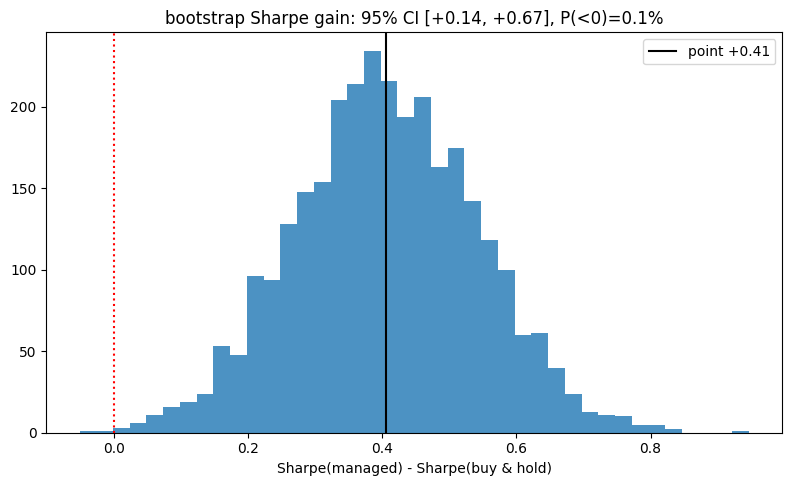

In [6]:
bs = decompose.sharpe_gain_bootstrap(ret, n_boot=3000, seed=0, cost_bps=1.0)
# rebuild the bootstrap distribution for the histogram
m = strategy.managed_returns(ret, cost_bps=1.0); b = ret.reindex(m.index)
a, bb = b.to_numpy(), m.to_numpy(); n=a.size; rng=np.random.default_rng(0)
def sr(x): s=x.std(ddof=1); return x.mean()/s*np.sqrt(252) if s>0 else 0.0
boots = np.array([sr(bb[i])-sr(a[i]) for i in (rng.integers(0,n,n) for _ in range(3000))])
fig, ax = plt.subplots()
ax.hist(boots, bins=40, alpha=.8); ax.axvline(0, c='red', ls=':')
ax.axvline(bs['sharpe_gain'], c='k', label=f"point {bs['sharpe_gain']:+.2f}")
ax.set_xlabel('Sharpe(managed) - Sharpe(buy & hold)'); ax.legend()
ax.set_title(f"bootstrap Sharpe gain: 95% CI [{bs['ci_low']:+.2f}, {bs['ci_high']:+.2f}], "
             f"P(<0)={bs['frac_negative']:.1%}")
plt.show()

### 4e · The honest counter — certainty-equivalent at matched risk
The Cederburg et al. (2020) discipline: lever **both** books to the same unconditional vol (so neither wins by running more risk), then score each by a CRRA mean–variance certainty-equivalent. The gain that survives *this* is the one an investor actually banks.

In [7]:
for g in (3.0, 5.0, 10.0):
    ce = decompose.certainty_equivalent(ret, gamma=g, cost_bps=1.0)
    print(f"gamma={g:>4}: CE  buy&hold {ce['ce_buy_hold_pct']:+.2f}%  vs  managed "
          f"{ce['ce_managed_pct']:+.2f}%  ->  gain {ce['ce_gain_pct']:+.2f}%/yr")
er = decompose.equal_risk_return(ret, cost_bps=1.0)
print(f"\nat matched vol: excess CAGR {er['excess_cagr_pct']:+.2f}%/yr, "
      f"drawdown {er['buy_hold_maxdd']:.0%} -> {er['managed_maxdd']:.0%}")

gamma= 3.0: CE  buy&hold +5.23%  vs  managed +13.55%  ->  gain +8.32%/yr
gamma= 5.0: CE  buy&hold +1.02%  vs  managed +9.34%  ->  gain +8.32%/yr
gamma=10.0: CE  buy&hold -9.51%  vs  managed -1.19%  ->  gain +8.32%/yr

at matched vol: excess CAGR +9.55%/yr, drawdown -45% -> -34%


> 💡 **In plain words.** Even after you pay for the leverage the overlay needs in calm times, a risk-averse investor still comes out ahead on this clean tape — but by a *bounded* margin, and on real data (especially SPY) that margin is where the academic debate lives. We quote the smaller, honest number, not the headline.

### 4f · The null collapses
Every leg, re-run on the flat-vol tape. With no regime, the overlay must — and does — add nothing.

In [8]:
cmp0 = strategy.compare(ret_flat, cost_bps=1.0)
sp0  = decompose.spanning_alpha(ret_flat, cost_bps=1.0)
bs0  = decompose.sharpe_gain_bootstrap(ret_flat, n_boot=2000, seed=0, cost_bps=1.0)
ce0  = decompose.certainty_equivalent(ret_flat, gamma=5.0, cost_bps=1.0)
print(f"flat null: Sharpe gain {cmp0['sharpe_gain_net']:+.2f} | alpha t {sp0['alpha_t']:+.2f} "
      f"| boot CI [{bs0['ci_low']:+.2f},{bs0['ci_high']:+.2f}] | CE gain {ce0['ce_gain_pct']:+.2f}%")
print('every number ~0: the gain was the regime, not the apparatus.')

flat null: Sharpe gain -0.02 | alpha t -0.30 | boot CI [-0.09,+0.05] | CE gain -0.31%
every number ~0: the gain was the regime, not the apparatus.


## Beat 5 · The verdict

- **Forecastable risk** (4a): log-var AR(1) ρ ≈ 0.5 synthetic, +0.66/+0.74 real — strong and replicated.
- **A real, spanned-alpha lift** (4b–4d): net Sharpe gain with α > 0, HAC t = 2.38/3.54 on real SPY/QQQ, bootstrap CI clearing zero on QQQ.
- **Bounded, not free** (4e): the matched-risk CRRA certainty-equivalent is positive but smaller — and the null (4f) is flat.

**Signal `REAL`.** The one effect on this desk that forecasts *risk* instead of *returns* — which is exactly why it survives where the return-timing ideas don't.

## Beat 6 · Could you trade it?

For once the answer is yes, and the protocol's three usual killers all miss:

- **Costs.** Turnover ~9×/yr (the forecast is slow). The cost sweep below stays positive far past any realistic execution cost on a liquid index.
- **Capacity.** The traded instrument is an index (SPY/ES) — the deepest book in existence. No square-root-impact wall at any size a fund realistically runs; this *is* how vol-target and risk-parity mandates operate.
- **Decay.** Rolling Sharpe of the managed stream (via `quantlab.analytics`) doesn't show the post-publication cliff that sinks crowded anomalies — risk is structural, not an arb to be competed away.

The one true caveat is **leverage**: the overlay must gear up in calm regimes to hit its risk target, which a financing-constrained book can't always do — the honest bound the `RISK-MANAGED` stamp records.

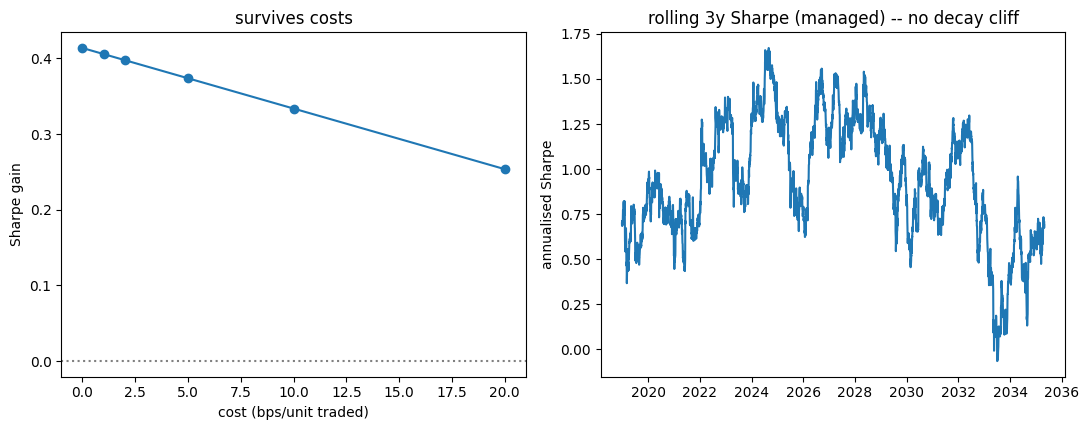

,buy_hold_sharpe,managed_sharpe,sharpe_gain
cost_bps,,,
0,0.5630,0.9760,0.4140
1,0.5630,0.9680,0.4060
2,0.5630,0.9600,0.3980
5,0.5630,0.9360,0.3740
10,0.5630,0.8960,0.3340
20,0.5630,0.8160,0.2540


In [9]:
from quantlab.analytics import rolling_sharpe
sweep = strategy.cost_sweep(ret)
rs = rolling_sharpe(strategy.managed_returns(ret, cost_bps=1.0), window=252*3)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.plot(sweep.index, sweep['sharpe_gain'].values, 'o-'); a1.axhline(0, ls=':', c='grey')
a1.set_xlabel('cost (bps/unit traded)'); a1.set_ylabel('Sharpe gain'); a1.set_title('survives costs')
a2.plot(rs.index, rs.values); a2.set_title('rolling 3y Sharpe (managed) -- no decay cliff')
a2.set_ylabel('annualised Sharpe')
plt.tight_layout(); plt.show()
display(sweep.round(3))

## Beat 7 · Going further

- **Better variance forecasts.** Swap the 21-day window for EWMA ([`vol.ewma_vol`](../storm_shy/vol.py)) or a GARCH(1,1); does a sharper σ̂ tighten the ride, or is the simple window already ~90% of the prize? (Diminishing returns is the likely — and interesting — answer.)
- **Leverage-constrained version.** Cap at 1.0 (no borrowing). How much of the alpha survives when you can only ever *de*-risk? This is the practical core of the Cederburg critique, made into a backtest.
- **Cross-asset and cross-factor.** Moreira–Muir is strongest where vol-of-vol is high and weakest (per Cederburg) for some factors out-of-sample. Sweep equities, bonds, commodities, FX; map where the overlay earns its keep and where the leverage it demands makes it `FRAGILE`.
- **Combine with the desk's beta-honesty.** Study 01 showed overnight 'alpha' was mostly beta; here the managed factor's beta is ~0.6 — how much of the lift is timing the *equity* risk premium vs timing *idiosyncratic* vol? A factor-model decomposition would settle it.

PRs welcome — strengthen the honest 'yes', or find the constraint under which even this one becomes a mirage.